<a href="https://colab.research.google.com/github/SunMingYang04/CS229N-/blob/main/CS231_Minimal_Neural_Network_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CS231N

## minimal neural network case sturdy

### generating some data（螺旋数据集）

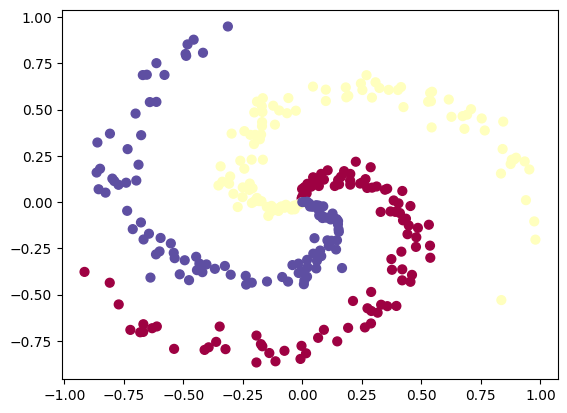

iteration 0: loss 1.107258
iteration 10: loss 0.919769
iteration 20: loss 0.852265
iteration 30: loss 0.822467
iteration 40: loss 0.807390
iteration 50: loss 0.799053
iteration 60: loss 0.794155
iteration 70: loss 0.791151
iteration 80: loss 0.789249
iteration 90: loss 0.788014
iteration 100: loss 0.787198
iteration 110: loss 0.786651
iteration 120: loss 0.786279
iteration 130: loss 0.786024
iteration 140: loss 0.785848
iteration 150: loss 0.785725
iteration 160: loss 0.785640
iteration 170: loss 0.785580
iteration 180: loss 0.785537
iteration 190: loss 0.785507
training accuracy: 0.53


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 超参数定义
reg = 1e-3 # 正则化强度
step_size = 1e-0 # 学习率

N=100   #每个类的点数
D=2    #维度
K=3    #类的数量
X=np.zeros((N*K,D))       #数据矩阵（每一行=单独例子）
y=np.zeros(N*K,dtype='uint8')  #类标签
for j in range(K):
  ix=range(N*j,N*(j+1))
  r=np.linspace(0.0,1,N)  #radius
  t=np.linspace(j*4,(j+1)*4,N)+np.random.randn(N)*0.2 #theta
  X[ix]=np.c_[r*np.sin(t),r*np.cos(t)]
  y[ix]=j
#数据可视化
plt.scatter(X[:,0],X[:,1],c=y,s=40,cmap=plt.cm.Spectral)
plt.show()

#随机初始化参数
W=0.1*np.random.randn(D,K)
b=np.zeros((1,K))

# 迭代训练
for i in range(200):
  # 计算线性分类器的分类得分
  scores=np.dot(X,W)+b

  num_examples=X.shape[0]
  # 得到非标准化的概率
  exp_scores=np.exp(scores)
  # 标准化实例
  probs=exp_scores/np.sum(exp_scores,axis=1,keepdims=True)
  correct_logprobs=-np.log(probs[range(num_examples),y])

  # 计算全损失：平均交叉熵损失（数据损失）和正则化损失
  data_loss=np.sum(correct_logprobs)/num_examples
  reg_loss=0.5*reg*np.sum(W*W)
  loss=data_loss+reg_loss

  if i % 10 == 0:
    print("iteration %d: loss %f" % (i, loss))

  # 计算梯度
  dscores=probs
  dscores[range(num_examples),y]-=1
  dscores/=num_examples

  dW=np.dot(X.T,dscores)
  db=np.sum(dscores,axis=0,keepdims=True)

  dW+=reg*W

  # 参数更新
  W+=-step_size*dW
  b+=-step_size*db

  # evaluate training set accuracy
scores = np.dot(X, W) + b
predicted_class = np.argmax(scores, axis=1)
print('training accuracy: %.2f' % (np.mean(predicted_class == y)))

In [7]:
import numpy as np

# initialize parameters randomly
h = 100 # size of hidden layer
W = 0.01 * np.random.randn(D,h)
b = np.zeros((1,h))
W2 = 0.01 * np.random.randn(h,K)
b2 = np.zeros((1,K))

# some hyperparameters
step_size = 1e-0
reg = 1e-3 # regularization strength

# gradient descent loop
num_examples = X.shape[0]
for i in range(10000):

  # evaluate class scores, [N x K]
  hidden_layer = np.maximum(0, np.dot(X, W) + b) # note, ReLU activation
  scores = np.dot(hidden_layer, W2) + b2

  # compute the class probabilities
  exp_scores = np.exp(scores)
  probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True) # [N x K]

  # compute the loss: average cross-entropy loss and regularization
  correct_logprobs = -np.log(probs[range(num_examples),y])
  data_loss = np.sum(correct_logprobs)/num_examples
  reg_loss = 0.5*reg*np.sum(W*W) + 0.5*reg*np.sum(W2*W2)
  loss = data_loss + reg_loss
  if i % 1000 == 0:
    print("iteration %d: loss %f" % (i, loss))

  # compute the gradient on scores
  dscores = probs
  dscores[range(num_examples),y] -= 1
  dscores /= num_examples

  # backpropate the gradient to the parameters
  # first backprop into parameters W2 and b2
  dW2 = np.dot(hidden_layer.T, dscores)
  db2 = np.sum(dscores, axis=0, keepdims=True)
  # next backprop into hidden layer
  dhidden = np.dot(dscores, W2.T)
  # backprop the ReLU non-linearity
  dhidden[hidden_layer <= 0] = 0
  # finally into W,b
  dW = np.dot(X.T, dhidden)
  db = np.sum(dhidden, axis=0, keepdims=True)

  # add regularization gradient contribution
  dW2 += reg * W2
  dW += reg * W

  # perform a parameter update
  W += -step_size * dW
  b += -step_size * db
  W2 += -step_size * dW2
  b2 += -step_size * db2

# evaluate training set accuracy
hidden_layer = np.maximum(0, np.dot(X, W) + b)
scores = np.dot(hidden_layer, W2) + b2
predicted_class = np.argmax(scores, axis=1)
print('training accuracy: %.2f' % (np.mean(predicted_class == y)))

iteration 0: loss 1.098621
iteration 1000: loss 0.341916
iteration 2000: loss 0.267614
iteration 3000: loss 0.259934
iteration 4000: loss 0.257939
iteration 5000: loss 0.257348
iteration 6000: loss 0.257105
iteration 7000: loss 0.256959
iteration 8000: loss 0.256852
iteration 9000: loss 0.256773
training accuracy: 0.99
